 # YOLO vs RT-DETR: Chess Piece Detection Benchmark Comparison

 This notebook compares the performance of YOLO and RT-DETR models for chess piece detection.
 
 **Background:**
 - We trained both YOLO and RT-DETR models on the same chess dataset
 - Dataset structure is identical for both models (YOLO format)
 - Training process is the same: just run yolo_train.py or rt_train.py

 **Comparison Goals:**
 - Model accuracy comparison on validation set
 - Confusion matrix analysis
 - Training curve comparison
 - Per-class performance analysis
 - Overall performance metrics

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
from pathlib import Path
import time
from ultralytics import YOLO, RTDETR
from sklearn.metrics import confusion_matrix
from collections import defaultdict

# Model paths
YOLO_MODEL_PATH = 'yolo_chess_model.pt'
RTDETR_MODEL_PATH = 'rt_chess_model.pt'

# Dataset paths
DATASET_PATH = 'yolo_ds'
ANNOTATIONS_PATH = 'annotations.json'

# Results paths for training curves
YOLO_RUNS_PATH = 'runs/yolo'
RTDETR_RUNS_PATH = 'runs/rt'

 ## Step 1: Load Models and Dataset

 Load both trained models and prepare the validation dataset for comparison.

In [5]:
def load_models():
    """Load both YOLO and RT-DETR models"""
    print("Loading models...")
    
    if not os.path.exists(YOLO_MODEL_PATH):
        raise FileNotFoundError(f"YOLO model not found: {YOLO_MODEL_PATH}")
    if not os.path.exists(RTDETR_MODEL_PATH):
        raise FileNotFoundError(f"RT-DETR model not found: {RTDETR_MODEL_PATH}")
    
    yolo_model = YOLO(YOLO_MODEL_PATH)
    rtdetr_model = RTDETR(RTDETR_MODEL_PATH)
    
    print(f"YOLO model loaded: {len(yolo_model.names)} classes")
    print(f"RT-DETR model loaded: {len(rtdetr_model.names)} classes")
    
    return yolo_model, rtdetr_model

def load_validation_dataset():
    """Load validation dataset images"""
    val_images_dir = Path(DATASET_PATH) / 'images' / 'val'
    val_labels_dir = Path(DATASET_PATH) / 'labels' / 'val'
    
    if not val_images_dir.exists():
        raise FileNotFoundError(f"Validation images directory not found: {val_images_dir}")
    
    image_files = []
    for ext in ['*.jpg', '*.jpeg', '*.png']:
        image_files.extend(list(val_images_dir.glob(ext)))
    
    print(f"Found {len(image_files)} validation images")
    
    ground_truth = {}
    for img_file in image_files:
        label_file = val_labels_dir / f"{img_file.stem}.txt"
        if label_file.exists():
            with open(label_file, 'r') as f:
                labels = []
                for line in f:
                    parts = line.strip().split()
                    if len(parts) == 5:
                        class_id = int(parts[0])
                        bbox = [float(x) for x in parts[1:]]
                        labels.append({'class': class_id, 'bbox': bbox})
                ground_truth[str(img_file)] = labels
    
    return image_files, ground_truth

yolo_model, rtdetr_model = load_models()
val_images, ground_truth = load_validation_dataset()

class_names = list(yolo_model.names.values())
print(f"Class names: {class_names}")

Loading models...
YOLO model loaded: 13 classes
RT-DETR model loaded: 13 classes
Found 330 validation images
Class names: ['white-pawn', 'white-rook', 'white-knight', 'white-bishop', 'white-queen', 'white-king', 'black-pawn', 'black-rook', 'black-knight', 'black-bishop', 'black-queen', 'black-king', 'empty']


 ## Step 2: Run Inference on Validation Set

 Run both models on the validation dataset and collect predictions for comparison.

In [6]:
def run_model_inference(model, images, model_name, conf_threshold=0.25):
    """Run inference on validation images and collect results"""
    print(f"\nRunning {model_name} inference on {len(images)} images...")
    
    predictions = {}
    inference_times = []
    
    for i, img_path in enumerate(images):
        if i % 50 == 0:
            print(f"  Processing {i+1}/{len(images)}")
        
        start_time = time.time()
        results = model(str(img_path), conf=conf_threshold, verbose=False)
        inference_time = time.time() - start_time
        inference_times.append(inference_time)
        
        result = results[0]
        preds = []
        
        if result.boxes is not None:
            boxes = result.boxes.xyxy.cpu().numpy()
            confidences = result.boxes.conf.cpu().numpy()
            class_ids = result.boxes.cls.cpu().numpy().astype(int)
            
            for box, conf, class_id in zip(boxes, confidences, class_ids):
                img = cv2.imread(str(img_path))
                h, w = img.shape[:2]
                x1, y1, x2, y2 = box
                x_center = ((x1 + x2) / 2) / w
                y_center = ((y1 + y2) / 2) / h
                width = (x2 - x1) / w
                height = (y2 - y1) / h
                
                preds.append({
                    'class': class_id,
                    'confidence': conf,
                    'bbox': [x_center, y_center, width, height]
                })
        
        predictions[str(img_path)] = preds
    
    avg_inference_time = np.mean(inference_times)
    print(f"{model_name} inference completed")
    print(f"   Average inference time: {avg_inference_time:.4f} seconds")
    print(f"   FPS: {1/avg_inference_time:.1f}")
    
    return predictions, inference_times

print("Starting model inference comparison...")
yolo_predictions, yolo_times = run_model_inference(yolo_model, val_images, "YOLO")
rtdetr_predictions, rtdetr_times = run_model_inference(rtdetr_model, val_images, "RT-DETR")

Starting model inference comparison...

Running YOLO inference on 330 images...
  Processing 1/330
  Processing 51/330
  Processing 101/330
  Processing 151/330
  Processing 201/330
  Processing 251/330
  Processing 301/330
YOLO inference completed
   Average inference time: 0.0693 seconds
   FPS: 14.4

Running RT-DETR inference on 330 images...
  Processing 1/330
  Processing 51/330
  Processing 101/330
  Processing 151/330
  Processing 201/330
  Processing 251/330
  Processing 301/330
RT-DETR inference completed
   Average inference time: 0.1158 seconds
   FPS: 8.6


 ## Step 3: Performance Metrics Calculation

 Calculate performance metrics for both models.

In [7]:
def calculate_iou(box1, box2):
    """Calculate IoU between two bounding boxes (normalized coordinates)"""
    def center_to_corner(bbox):
        x_center, y_center, width, height = bbox
        x1 = x_center - width / 2
        y1 = y_center - height / 2
        x2 = x_center + width / 2
        y2 = y_center + height / 2
        return [x1, y1, x2, y2]
    
    box1_corner = center_to_corner(box1)
    box2_corner = center_to_corner(box2)
    
    x1 = max(box1_corner[0], box2_corner[0])
    y1 = max(box1_corner[1], box2_corner[1])
    x2 = min(box1_corner[2], box2_corner[2])
    y2 = min(box1_corner[3], box2_corner[3])
    
    if x2 <= x1 or y2 <= y1:
        return 0.0
    
    intersection = (x2 - x1) * (y2 - y1)
    
    area1 = (box1_corner[2] - box1_corner[0]) * (box1_corner[3] - box1_corner[1])
    area2 = (box2_corner[2] - box2_corner[0]) * (box2_corner[3] - box2_corner[1])
    union = area1 + area2 - intersection
    
    return intersection / union if union > 0 else 0.0

def evaluate_predictions(predictions, ground_truth, iou_threshold=0.5):
    """Evaluate predictions against ground truth"""
    
    all_pred_classes = []
    all_true_classes = []
    
    class_tp = defaultdict(int)
    class_fp = defaultdict(int)
    class_fn = defaultdict(int)
    
    total_detections = 0
    total_ground_truth = 0
    
    for img_path in ground_truth.keys():
        if img_path not in predictions:
            continue
            
        gt_boxes = ground_truth[img_path]
        pred_boxes = predictions[img_path]
        
        total_ground_truth += len(gt_boxes)
        total_detections += len(pred_boxes)
        
        gt_matched = [False] * len(gt_boxes)
        
        for pred in pred_boxes:
            pred_class = pred['class']
            pred_bbox = pred['bbox']
            
            best_iou = 0
            best_gt_idx = -1
            
            for gt_idx, gt in enumerate(gt_boxes):
                if gt_matched[gt_idx]:
                    continue
                    
                gt_class = gt['class']
                gt_bbox = gt['bbox']
                
                if pred_class == gt_class:
                    iou = calculate_iou(pred_bbox, gt_bbox)
                    if iou > best_iou:
                        best_iou = iou
                        best_gt_idx = gt_idx
            
            if best_iou >= iou_threshold:
                class_tp[pred_class] += 1
                gt_matched[best_gt_idx] = True
                all_pred_classes.append(pred_class)
                all_true_classes.append(pred_class)
            else:
                class_fp[pred_class] += 1
                all_pred_classes.append(pred_class)
                all_true_classes.append(-1)
        
        for gt_idx, gt in enumerate(gt_boxes):
            if not gt_matched[gt_idx]:
                class_fn[gt['class']] += 1
                all_pred_classes.append(-1)
                all_true_classes.append(gt['class'])
    
    results = {
        'total_detections': total_detections,
        'total_ground_truth': total_ground_truth,
        'class_metrics': {},
        'overall_metrics': {},
        'confusion_matrix_data': (all_true_classes, all_pred_classes)
    }
    
    total_tp = 0
    total_fp = 0
    total_fn = 0
    
    for class_id in range(len(class_names)):
        tp = class_tp[class_id]
        fp = class_fp[class_id]
        fn = class_fn[class_id]
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        results['class_metrics'][class_id] = {
            'class_name': class_names[class_id],
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'tp': tp,
            'fp': fp,
            'fn': fn
        }
        
        total_tp += tp
        total_fp += fp
        total_fn += fn
    
    overall_precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
    overall_recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
    overall_f1 = 2 * (overall_precision * overall_recall) / (overall_precision + overall_recall) if (overall_precision + overall_recall) > 0 else 0
    
    results['overall_metrics'] = {
        'precision': overall_precision,
        'recall': overall_recall,
        'f1': overall_f1,
        'total_tp': total_tp,
        'total_fp': total_fp,
        'total_fn': total_fn
    }
    
    return results

print("Evaluating model performance...")
yolo_results = evaluate_predictions(yolo_predictions, ground_truth)
rtdetr_results = evaluate_predictions(rtdetr_predictions, ground_truth)

print("Performance evaluation completed")

Evaluating model performance...
Performance evaluation completed


 ## Step 4: Confusion Matrix Comparison

Generating confusion matrices...


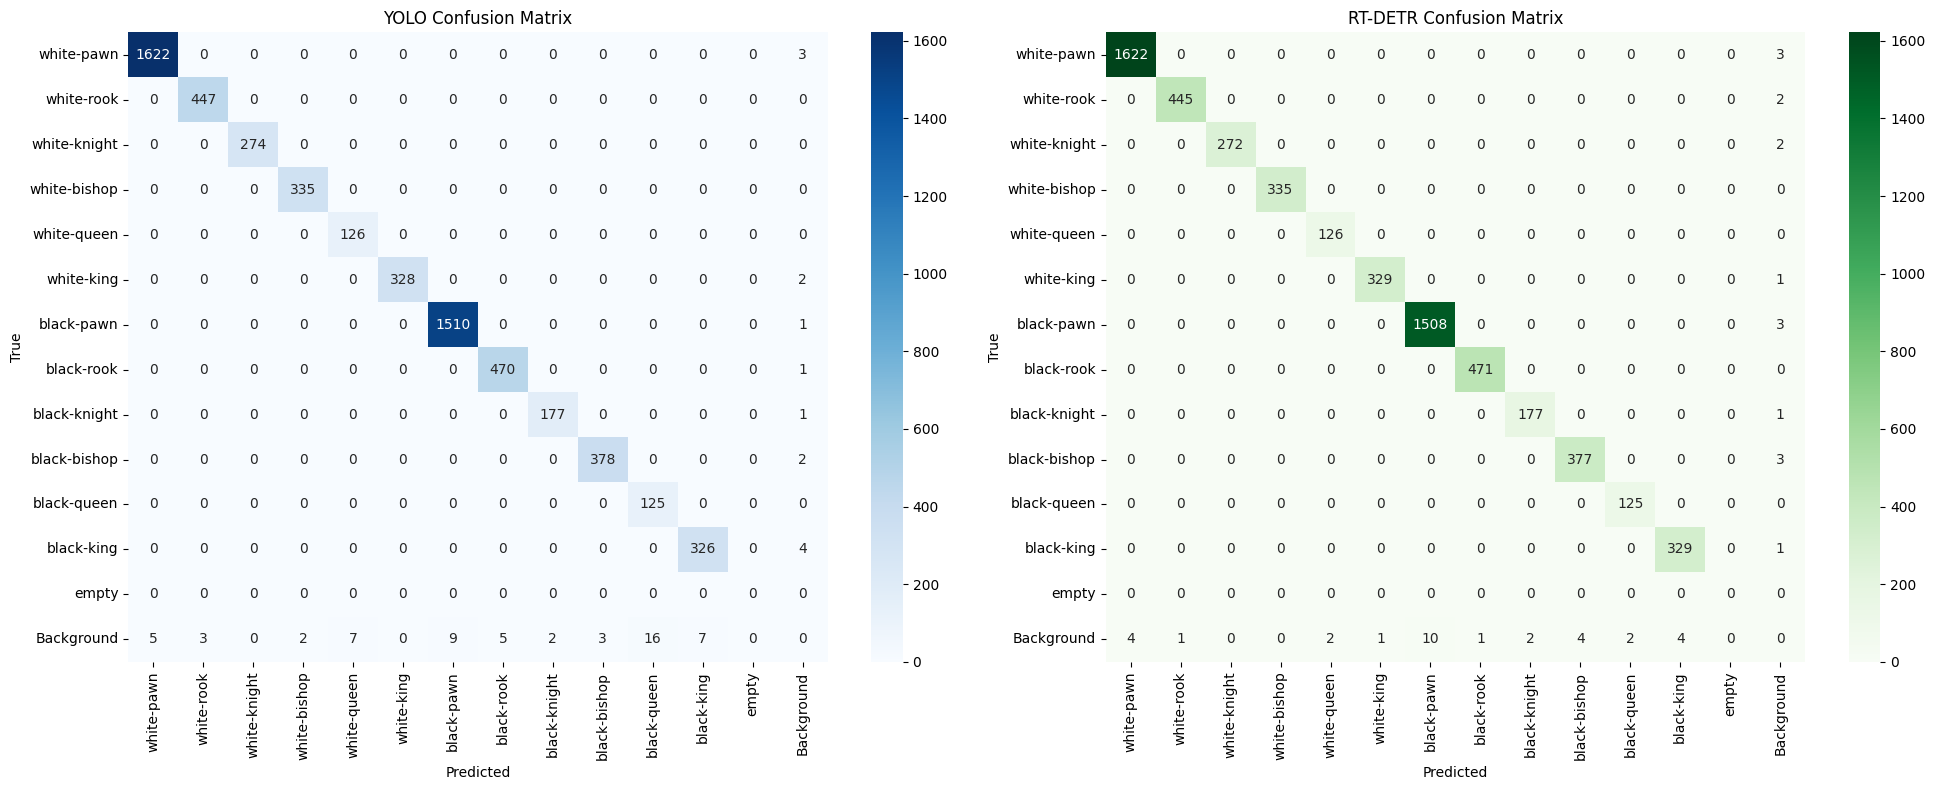

In [8]:
def plot_confusion_matrices(yolo_results, rtdetr_results, class_names):
    """Plot confusion matrices for both models side by side"""
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    
    y_true_yolo, y_pred_yolo = yolo_results['confusion_matrix_data']
    
    y_true_yolo_mapped = [c if c != -1 else len(class_names) for c in y_true_yolo]
    y_pred_yolo_mapped = [c if c != -1 else len(class_names) for c in y_pred_yolo]
    
    labels = list(range(len(class_names) + 1))
    cm_yolo = confusion_matrix(y_true_yolo_mapped, y_pred_yolo_mapped, labels=labels)
    
    class_labels = class_names + ['Background']
    sns.heatmap(cm_yolo, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_labels, yticklabels=class_labels, ax=ax1)
    ax1.set_title('YOLO Confusion Matrix')
    ax1.set_xlabel('Predicted')
    ax1.set_ylabel('True')
    
    y_true_rtdetr, y_pred_rtdetr = rtdetr_results['confusion_matrix_data']
    
    y_true_rtdetr_mapped = [c if c != -1 else len(class_names) for c in y_true_rtdetr]
    y_pred_rtdetr_mapped = [c if c != -1 else len(class_names) for c in y_pred_rtdetr]
    
    cm_rtdetr = confusion_matrix(y_true_rtdetr_mapped, y_pred_rtdetr_mapped, labels=labels)
    
    sns.heatmap(cm_rtdetr, annot=True, fmt='d', cmap='Greens', 
                xticklabels=class_labels, yticklabels=class_labels, ax=ax2)
    ax2.set_title('RT-DETR Confusion Matrix')
    ax2.set_xlabel('Predicted')
    ax2.set_ylabel('True')
    
    plt.tight_layout()
    plt.show()
    
    return cm_yolo, cm_rtdetr

print("Generating confusion matrices...")
cm_yolo, cm_rtdetr = plot_confusion_matrices(yolo_results, rtdetr_results, class_names)

 ## Step 5: Training Curves Comparison

Loading training results...
Loaded YOLO training results: 100 epochs
Loaded RT-DETR training results: 100 epochs


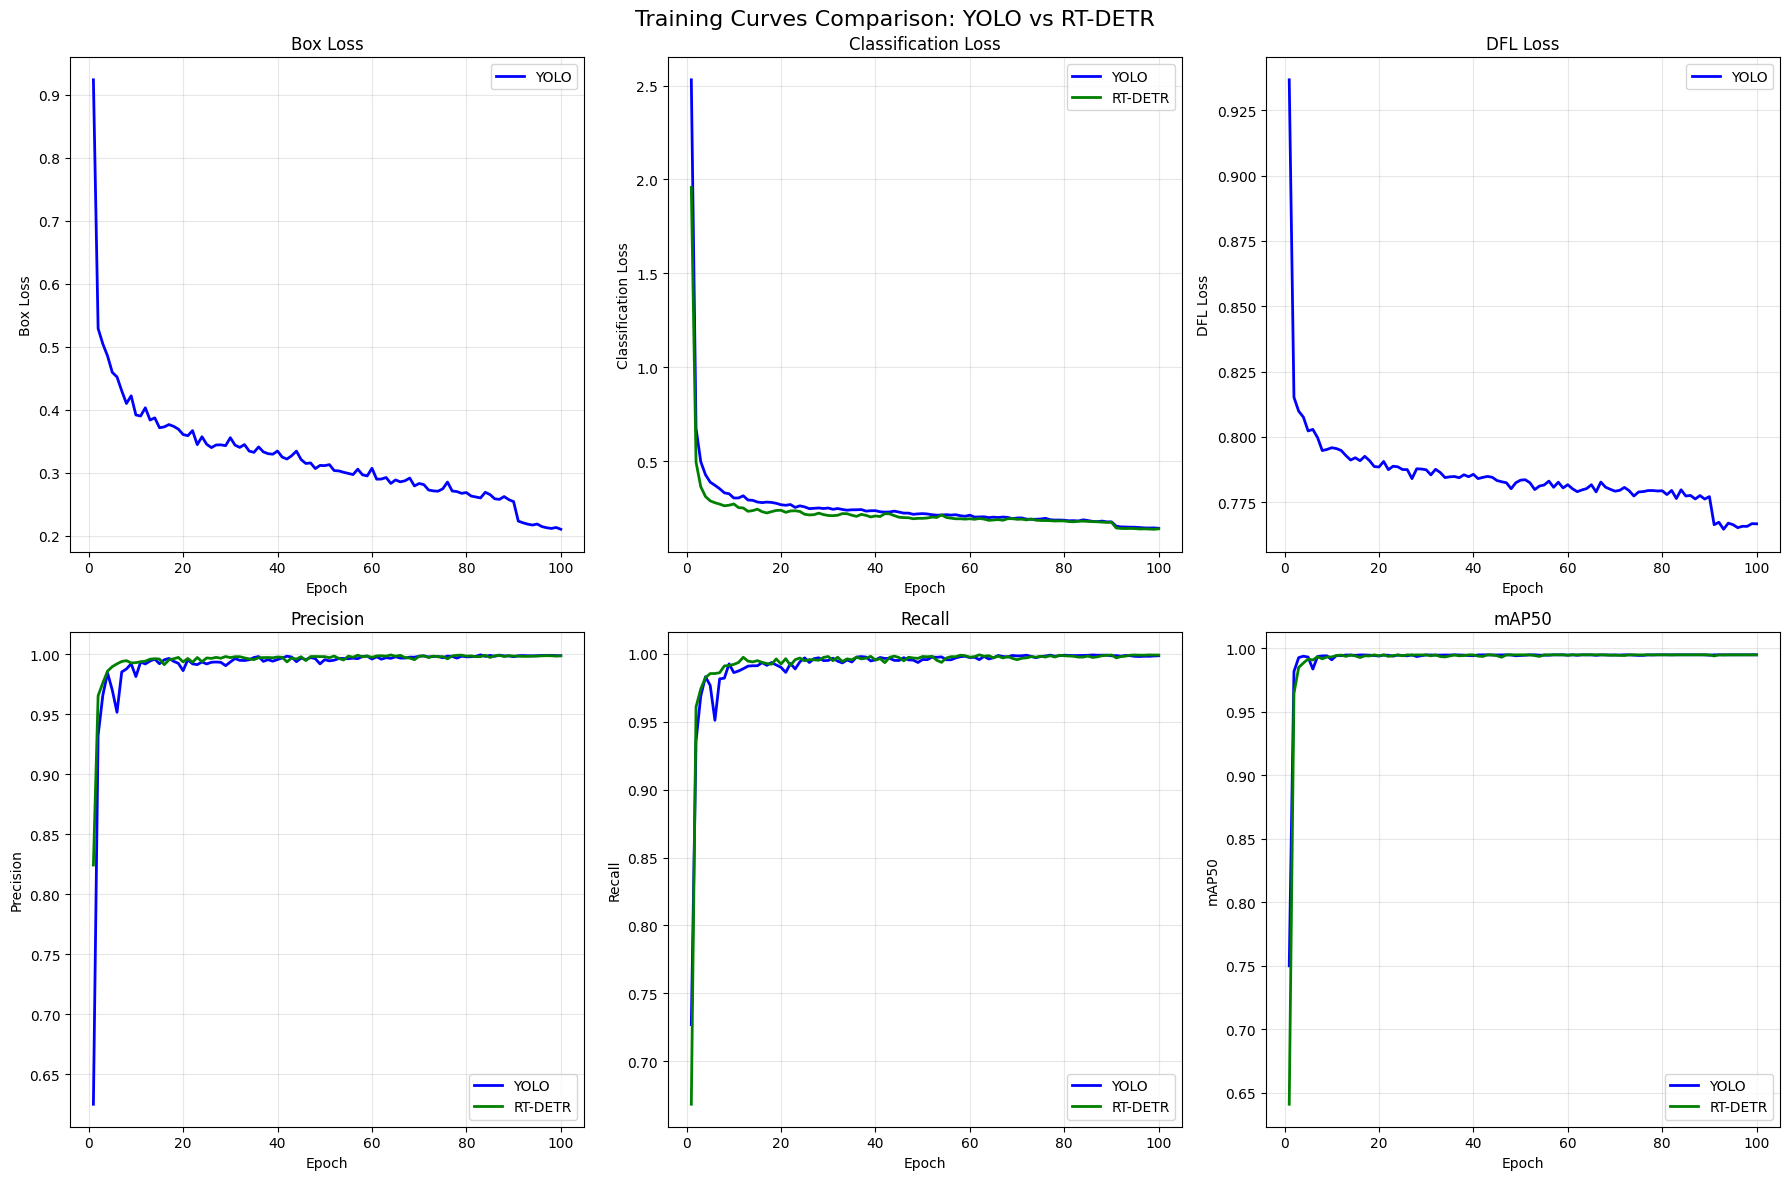

In [9]:
def load_training_results(results_path, model_name):
    """Load training results from results.csv"""
    results_file = Path(results_path) / 'results.csv'
    
    if not results_file.exists():
        print(f"Warning: {model_name} results file not found: {results_file}")
        return None
    
    try:
        df = pd.read_csv(results_file)
        df.columns = df.columns.str.strip()
        print(f"Loaded {model_name} training results: {len(df)} epochs")
        return df
    except Exception as e:
        print(f"Error loading {model_name} results: {e}")
        return None

def plot_training_curves(yolo_df, rtdetr_df):
    """Plot training curves comparison"""
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Training Curves Comparison: YOLO vs RT-DETR', fontsize=16)
    
    metrics = [
        ('train/box_loss', 'Box Loss'),
        ('train/cls_loss', 'Classification Loss'), 
        ('train/dfl_loss', 'DFL Loss'),
        ('metrics/precision(B)', 'Precision'),
        ('metrics/recall(B)', 'Recall'),
        ('metrics/mAP50(B)', 'mAP50')
    ]
    
    for idx, (metric_col, title) in enumerate(metrics):
        row = idx // 3
        col = idx % 3
        ax = axes[row, col]
        
        if yolo_df is not None and metric_col in yolo_df.columns:
            epochs = range(1, len(yolo_df) + 1)
            ax.plot(epochs, yolo_df[metric_col], label='YOLO', color='blue', linewidth=2)
        
        if rtdetr_df is not None and metric_col in rtdetr_df.columns:
            epochs = range(1, len(rtdetr_df) + 1)
            ax.plot(epochs, rtdetr_df[metric_col], label='RT-DETR', color='green', linewidth=2)
        
        ax.set_title(title)
        ax.set_xlabel('Epoch')
        ax.set_ylabel(title)
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print("Loading training results...")
yolo_df = load_training_results(YOLO_RUNS_PATH, "YOLO")
rtdetr_df = load_training_results(RTDETR_RUNS_PATH, "RT-DETR")

if yolo_df is not None or rtdetr_df is not None:
    plot_training_curves(yolo_df, rtdetr_df)
else:
    print("No training curves available to plot")

 ## Step 6: Detailed Performance Comparison

 Compare class-wise accuracy and overall performance metrics between both models.

Creating performance comparison...

DETAILED PERFORMANCE COMPARISON

Overall Performance:
Metric          YOLO       RT-DETR    Difference  
--------------------------------------------------
Precision       0.9904     0.9950     +0.0045
Recall          0.9977     0.9974     -0.0003
F1              0.9941     0.9962     +0.0021

Inference Speed:
Model           Avg Time (s)    FPS       
----------------------------------------
YOLO            0.0693          14.4      
RT-DETR         0.1158          8.6       

Class-wise Performance (Top 5 classes by F1 difference):
       Class  YOLO_F1  RTDETR_F1  F1_Diff
 black-queen   0.9398     0.9921   0.0522
 white-queen   0.9730     0.9921   0.0192
  black-king   0.9834     0.9925   0.0090
  black-rook   0.9937     0.9989   0.0053
white-bishop   0.9970     1.0000   0.0030


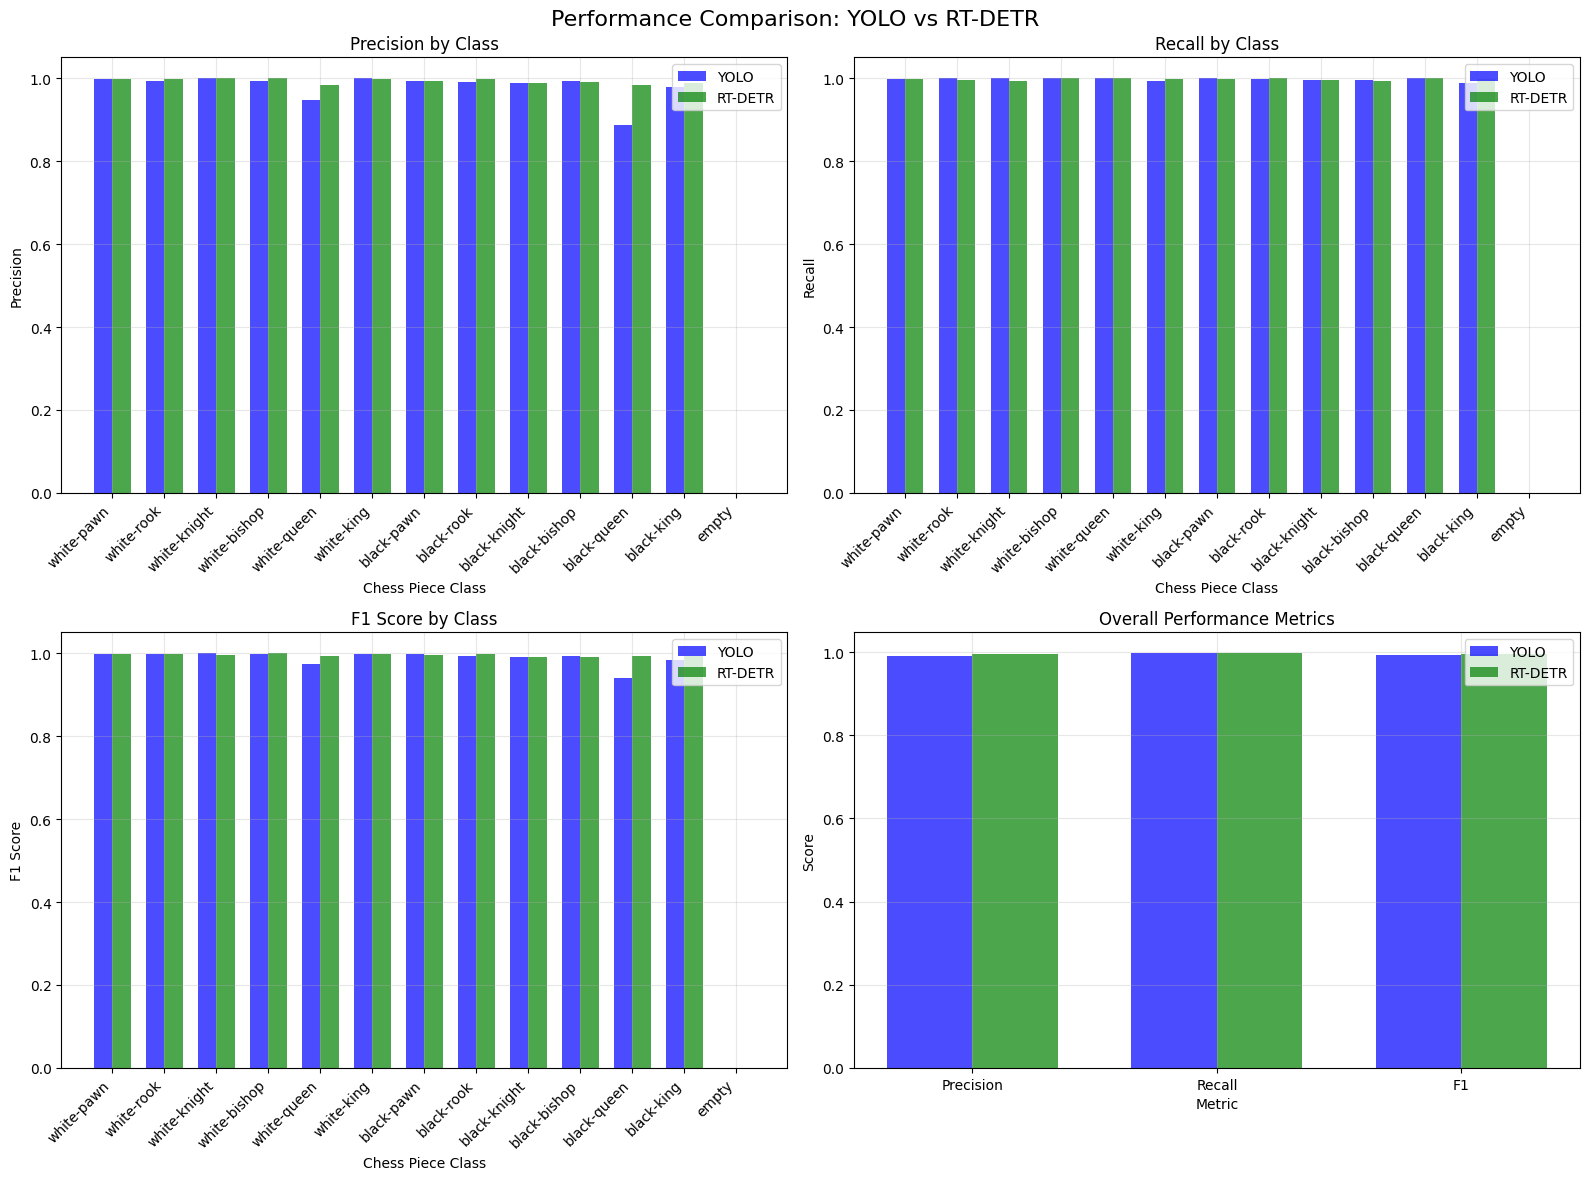


BENCHMARK COMPARISON COMPLETE


In [10]:
def create_performance_comparison_table(yolo_results, rtdetr_results):
    """Create detailed performance comparison table"""
    
    comparison_data = []
    
    for class_id in range(len(class_names)):
        yolo_metrics = yolo_results['class_metrics'][class_id]
        rtdetr_metrics = rtdetr_results['class_metrics'][class_id]
        
        comparison_data.append({
            'Class': class_names[class_id],
            'YOLO_Precision': yolo_metrics['precision'],
            'RTDETR_Precision': rtdetr_metrics['precision'],
            'YOLO_Recall': yolo_metrics['recall'],
            'RTDETR_Recall': rtdetr_metrics['recall'],
            'YOLO_F1': yolo_metrics['f1'],
            'RTDETR_F1': rtdetr_metrics['f1'],
            'YOLO_TP': yolo_metrics['tp'],
            'RTDETR_TP': rtdetr_metrics['tp'],
            'YOLO_FP': yolo_metrics['fp'],
            'RTDETR_FP': rtdetr_metrics['fp'],
            'YOLO_FN': yolo_metrics['fn'],
            'RTDETR_FN': rtdetr_metrics['fn']
        })
    
    df = pd.DataFrame(comparison_data)
    
    return df

def plot_performance_comparison(comparison_df):
    """Plot performance comparison charts"""
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Performance Comparison: YOLO vs RT-DETR', fontsize=16)
    
    x_pos = np.arange(len(comparison_df))
    width = 0.35
    
    axes[0,0].bar(x_pos - width/2, comparison_df['YOLO_Precision'], width, 
                  label='YOLO', color='blue', alpha=0.7)
    axes[0,0].bar(x_pos + width/2, comparison_df['RTDETR_Precision'], width, 
                  label='RT-DETR', color='green', alpha=0.7)
    axes[0,0].set_title('Precision by Class')
    axes[0,0].set_xlabel('Chess Piece Class')
    axes[0,0].set_ylabel('Precision')
    axes[0,0].set_xticks(x_pos)
    axes[0,0].set_xticklabels(comparison_df['Class'], rotation=45, ha='right')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)
    
    axes[0,1].bar(x_pos - width/2, comparison_df['YOLO_Recall'], width, 
                  label='YOLO', color='blue', alpha=0.7)
    axes[0,1].bar(x_pos + width/2, comparison_df['RTDETR_Recall'], width, 
                  label='RT-DETR', color='green', alpha=0.7)
    axes[0,1].set_title('Recall by Class')
    axes[0,1].set_xlabel('Chess Piece Class')
    axes[0,1].set_ylabel('Recall')
    axes[0,1].set_xticks(x_pos)
    axes[0,1].set_xticklabels(comparison_df['Class'], rotation=45, ha='right')
    axes[0,1].legend()
    axes[0,1].grid(True, alpha=0.3)
    
    axes[1,0].bar(x_pos - width/2, comparison_df['YOLO_F1'], width, 
                  label='YOLO', color='blue', alpha=0.7)
    axes[1,0].bar(x_pos + width/2, comparison_df['RTDETR_F1'], width, 
                  label='RT-DETR', color='green', alpha=0.7)
    axes[1,0].set_title('F1 Score by Class')
    axes[1,0].set_xlabel('Chess Piece Class')
    axes[1,0].set_ylabel('F1 Score')
    axes[1,0].set_xticks(x_pos)
    axes[1,0].set_xticklabels(comparison_df['Class'], rotation=45, ha='right')
    axes[1,0].legend()
    axes[1,0].grid(True, alpha=0.3)
    
    overall_metrics = ['Precision', 'Recall', 'F1']
    yolo_overall = [yolo_results['overall_metrics']['precision'],
                    yolo_results['overall_metrics']['recall'],
                    yolo_results['overall_metrics']['f1']]
    rtdetr_overall = [rtdetr_results['overall_metrics']['precision'],
                      rtdetr_results['overall_metrics']['recall'],
                      rtdetr_results['overall_metrics']['f1']]
    
    x_pos_overall = np.arange(len(overall_metrics))
    axes[1,1].bar(x_pos_overall - width/2, yolo_overall, width, 
                  label='YOLO', color='blue', alpha=0.7)
    axes[1,1].bar(x_pos_overall + width/2, rtdetr_overall, width, 
                  label='RT-DETR', color='green', alpha=0.7)
    axes[1,1].set_title('Overall Performance Metrics')
    axes[1,1].set_xlabel('Metric')
    axes[1,1].set_ylabel('Score')
    axes[1,1].set_xticks(x_pos_overall)
    axes[1,1].set_xticklabels(overall_metrics)
    axes[1,1].legend()
    axes[1,1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print("Creating performance comparison...")
comparison_df = create_performance_comparison_table(yolo_results, rtdetr_results)

print("\n" + "="*100)
print("DETAILED PERFORMANCE COMPARISON")
print("="*100)

print(f"\nOverall Performance:")
print(f"{'Metric':<15} {'YOLO':<10} {'RT-DETR':<10} {'Difference':<12}")
print("-" * 50)

yolo_overall = yolo_results['overall_metrics']
rtdetr_overall = rtdetr_results['overall_metrics']

for metric in ['precision', 'recall', 'f1']:
    yolo_val = yolo_overall[metric]
    rtdetr_val = rtdetr_overall[metric]
    diff = rtdetr_val - yolo_val
    print(f"{metric.capitalize():<15} {yolo_val:<10.4f} {rtdetr_val:<10.4f} {diff:+.4f}")

print(f"\nInference Speed:")
yolo_avg_time = np.mean(yolo_times)
rtdetr_avg_time = np.mean(rtdetr_times)
print(f"{'Model':<15} {'Avg Time (s)':<15} {'FPS':<10}")
print("-" * 40)
print(f"{'YOLO':<15} {yolo_avg_time:<15.4f} {1/yolo_avg_time:<10.1f}")
print(f"{'RT-DETR':<15} {rtdetr_avg_time:<15.4f} {1/rtdetr_avg_time:<10.1f}")

print(f"\nClass-wise Performance (Top 5 classes by F1 difference):")
comparison_df['F1_Diff'] = comparison_df['RTDETR_F1'] - comparison_df['YOLO_F1']
top_classes = comparison_df.nlargest(5, 'F1_Diff')[['Class', 'YOLO_F1', 'RTDETR_F1', 'F1_Diff']]
print(top_classes.to_string(index=False, float_format='%.4f'))

plot_performance_comparison(comparison_df)

print("\n" + "="*100)
print("BENCHMARK COMPARISON COMPLETE")
print("="*100)